In [1]:
# ============================================================
# PHASE 1 - SECTION 1
# ENVIRONMENT SETUP AND LIBRARY IMPORT
#
# Purpose:
# Initialize the development environment for UAV GNSS
# spoofing and jamming detection framework
# ============================================================


# -----------------------------
# Import Required Libraries
# -----------------------------

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os
import random


# -----------------------------
# Machine Learning Utilities
# -----------------------------

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


# -----------------------------
# Visualization Settings
# -----------------------------

plt.style.use("default")


# -----------------------------
# Random Seed Configuration
# -----------------------------

SEED = 42

np.random.seed(SEED)
random.seed(SEED)


# -----------------------------
# Project Directory Setup
# -----------------------------

PROJECT_PATH = "./UAV_GNSS_Attack_Detection"

DATA_PATH = os.path.join(
    PROJECT_PATH,
    "dataset"
)

RESULT_PATH = os.path.join(
    PROJECT_PATH,
    "results"
)


# Create directories

os.makedirs(DATA_PATH, exist_ok=True)
os.makedirs(RESULT_PATH, exist_ok=True)


print("Environment setup completed successfully.")
print("Project directory:", PROJECT_PATH)

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Environment setup completed successfully.
Project directory: ./UAV_GNSS_Attack_Detection


In [2]:
# ============================================================
# PHASE 1 - SECTION 2
# DATASET LOADING AND INITIAL VALIDATION
#
# Dataset:
# UAV Autonomous Navigation Dataset
#
# Contains:
# - GNSS measurements
# - IMU readings
# - UAV telemetry
# ============================================================


# Dataset location

dataset_file = "uav_navigation_dataset.csv"


# Load dataset

df = pd.read_csv(dataset_file)


# Display basic information

print("Dataset Loaded Successfully")

print("--------------------------------")

print("Number of Samples:",
      df.shape[0])

print("Number of Features:",
      df.shape[1])


print("--------------------------------")

print("Dataset Columns:")

for col in df.columns:
    print(col)


# Display first samples

df.head()

Dataset Loaded Successfully
--------------------------------
Number of Samples: 5000
Number of Features: 15
--------------------------------
Dataset Columns:
timestamp
latitude
longitude
altitude
imu_acc_x
imu_acc_y
imu_acc_z
imu_gyro_x
imu_gyro_y
imu_gyro_z
lidar_distance
speed
wind_speed
battery_level
obstacle_detected


,timestamp,latitude,longitude,altitude,imu_acc_x,imu_acc_y,imu_acc_z,imu_gyro_x,imu_gyro_y,imu_gyro_z,lidar_distance,speed,wind_speed,battery_level,obstacle_detected
0,2023-01-01 00:00:00,37.772391,-122.421527,218.138368,-0.001979,1.379990,-2.445775,49.732045,39.381347,-72.391665,33.328274,26.180914,1.768356,79.324416,0
1,2023-01-01 00:00:01,37.783914,-122.419931,199.810443,1.480481,-1.892928,-2.635478,-14.654717,-165.994752,-145.865601,81.765473,17.362926,0.287489,90.488150,0
2,2023-01-01 00:00:02,37.779540,-122.412309,129.269261,0.376001,-0.920162,0.625152,167.219469,40.413723,-134.510679,99.440493,9.886640,14.688221,57.054390,0
3,2023-01-01 00:00:03,37.776873,-122.422600,323.270002,-2.500185,0.979684,2.796698,-101.167758,-147.719302,-114.958394,84.155773,23.416045,5.234081,43.134299,0
4,2023-01-01 00:00:04,37.768020,-122.412007,264.480872,-1.886519,-0.107464,0.016328,31.628310,75.723926,-106.684800,34.941221,15.466953,17.553565,45.507726,0


In [3]:
# ============================================================
# PHASE 1 - SECTION 3
# DATASET QUALITY ANALYSIS
#
# Checks:
# - Missing values
# - Data types
# - Duplicate records
# - Timestamp consistency
# ============================================================


# Dataset information

df.info()


# Missing value analysis

missing_values = df.isnull().sum()


print("\nMissing Values")
print("----------------")

print(missing_values)


# Duplicate checking

duplicates = df.duplicated().sum()


print("\nDuplicate Records:",
      duplicates)



# Timestamp conversion

df["timestamp"] = pd.to_datetime(
    df["timestamp"]
)


# Sort according to time

df = df.sort_values(
    by="timestamp"
)


print("\nTimestamp verification completed")


df.head()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          5000 non-null   str    
 1   latitude           5000 non-null   float64
 2   longitude          5000 non-null   float64
 3   altitude           5000 non-null   float64
 4   imu_acc_x          5000 non-null   float64
 5   imu_acc_y          5000 non-null   float64
 6   imu_acc_z          5000 non-null   float64
 7   imu_gyro_x         5000 non-null   float64
 8   imu_gyro_y         5000 non-null   float64
 9   imu_gyro_z         5000 non-null   float64
 10  lidar_distance     5000 non-null   float64
 11  speed              5000 non-null   float64
 12  wind_speed         5000 non-null   float64
 13  battery_level      5000 non-null   float64
 14  obstacle_detected  5000 non-null   int64  
dtypes: float64(13), int64(1), str(1)
memory usage: 678.8 KB

Missing Values
-----------

,timestamp,latitude,longitude,altitude,imu_acc_x,imu_acc_y,imu_acc_z,imu_gyro_x,imu_gyro_y,imu_gyro_z,lidar_distance,speed,wind_speed,battery_level,obstacle_detected
0,2023-01-01 00:00:00,37.772391,-122.421527,218.138368,-0.001979,1.379990,-2.445775,49.732045,39.381347,-72.391665,33.328274,26.180914,1.768356,79.324416,0
1,2023-01-01 00:00:01,37.783914,-122.419931,199.810443,1.480481,-1.892928,-2.635478,-14.654717,-165.994752,-145.865601,81.765473,17.362926,0.287489,90.488150,0
2,2023-01-01 00:00:02,37.779540,-122.412309,129.269261,0.376001,-0.920162,0.625152,167.219469,40.413723,-134.510679,99.440493,9.886640,14.688221,57.054390,0
3,2023-01-01 00:00:03,37.776873,-122.422600,323.270002,-2.500185,0.979684,2.796698,-101.167758,-147.719302,-114.958394,84.155773,23.416045,5.234081,43.134299,0
4,2023-01-01 00:00:04,37.768020,-122.412007,264.480872,-1.886519,-0.107464,0.016328,31.628310,75.723926,-106.684800,34.941221,15.466953,17.553565,45.507726,0


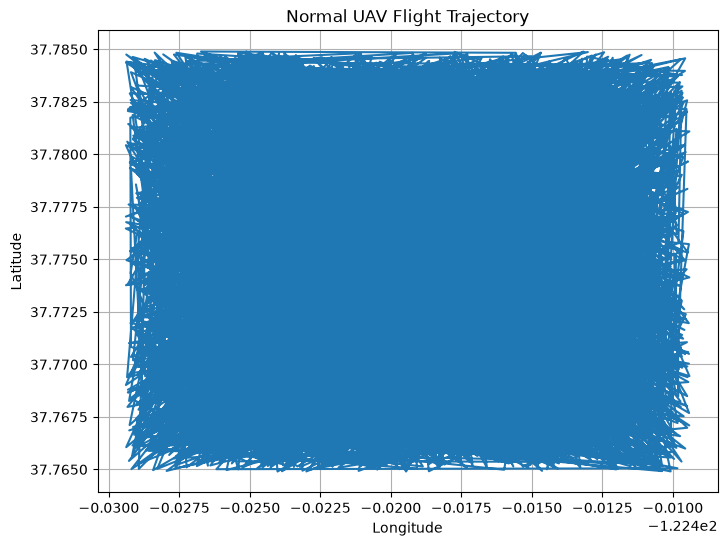

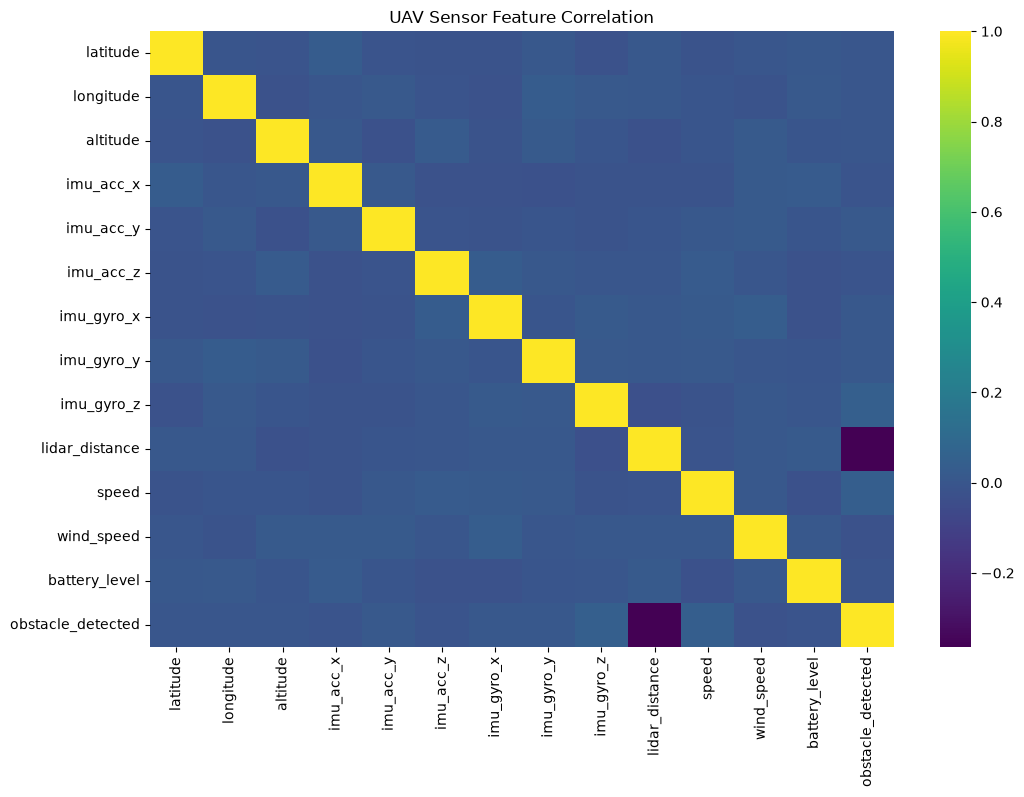

In [4]:
# ============================================================
# PHASE 1 - SECTION 4
# EXPLORATORY DATA ANALYSIS
#
# Visualisation of:
# - UAV trajectory
# - Sensor behaviour
# - Feature correlation
# ============================================================


# -----------------------------
# GPS Trajectory Plot
# -----------------------------


plt.figure(figsize=(8,6))


plt.plot(
    df["longitude"],
    df["latitude"]
)


plt.xlabel(
    "Longitude"
)

plt.ylabel(
    "Latitude"
)


plt.title(
    "Normal UAV Flight Trajectory"
)


plt.grid(True)

plt.show()



# -----------------------------
# Feature Correlation
# -----------------------------


plt.figure(figsize=(12,8))


sns.heatmap(
    df.corr(numeric_only=True),
    cmap="viridis"
)


plt.title(
    "UAV Sensor Feature Correlation"
)


plt.show()

In [5]:
# ============================================================
# PHASE 1 - SECTION 5
# SYNTHETIC GNSS SPOOFING ATTACK GENERATION
#
# Attack Types:
# 1. Gradual Drift Spoofing
# 2. Sudden Jump Spoofing
#
# Output:
# Spoofed UAV telemetry dataset
# ============================================================


import numpy as np
import pandas as pd



# ------------------------------------------------------------
# Create copy of original dataset
# ------------------------------------------------------------

spoofing_df = df.copy()



# ------------------------------------------------------------
# Function 1:
# Gradual Drift Spoofing Attack
# ------------------------------------------------------------

def apply_drift_attack(data, start_point, drift_strength):

    attacked_data = data.copy()


    attack_length = len(attacked_data) - start_point


    # gradual increasing offset

    drift_values = np.linspace(
        0,
        drift_strength,
        attack_length
    )


    attacked_data.loc[
        start_point:,
        "latitude"
    ] += drift_values



    attacked_data.loc[
        start_point:,
        "longitude"
    ] += drift_values



    return attacked_data





# ------------------------------------------------------------
# Function 2:
# Jump Spoofing Attack
# ------------------------------------------------------------

def apply_jump_attack(data, attack_point, latitude_shift, longitude_shift):

    attacked_data = data.copy()


    attacked_data.loc[
        attack_point:,
        "latitude"
    ] += latitude_shift


    attacked_data.loc[
        attack_point:,
        "longitude"
    ] += longitude_shift


    return attacked_data





# ------------------------------------------------------------
# Generate Drift Attack
# ------------------------------------------------------------

drift_attack_df = apply_drift_attack(
    spoofing_df,
    start_point=2500,
    drift_strength=0.002
)



# ------------------------------------------------------------
# Generate Jump Attack
# ------------------------------------------------------------

jump_attack_df = apply_jump_attack(
    spoofing_df,
    attack_point=3500,
    latitude_shift=0.01,
    longitude_shift=0.01
)



print("Spoofing attack generation completed.")

print(
    "Drift attack samples:",
    len(drift_attack_df)
)

print(
    "Jump attack samples:",
    len(jump_attack_df)
)

Spoofing attack generation completed.
Drift attack samples: 5000
Jump attack samples: 5000


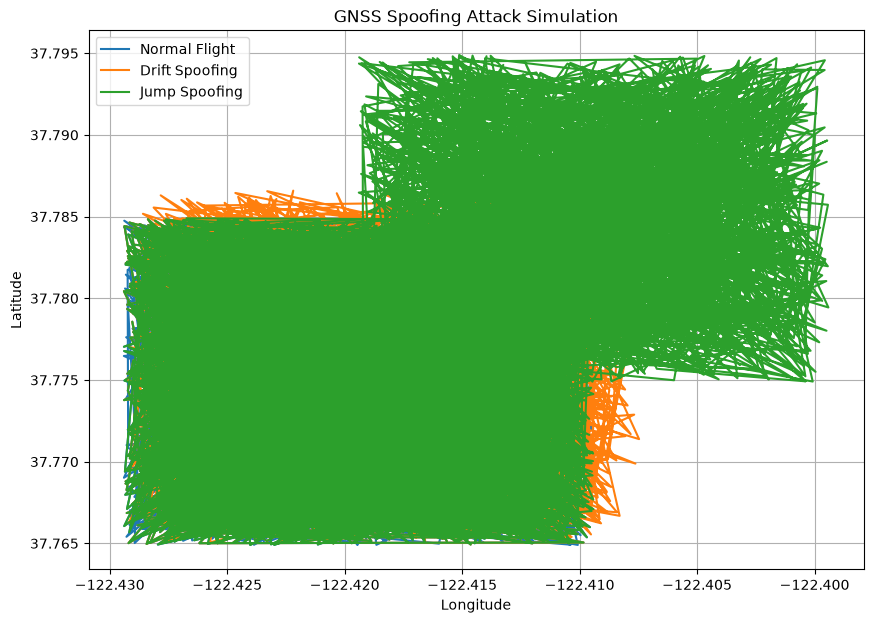

In [6]:
# ============================================================
# PHASE 1 - SECTION 6
# SPOOFING ATTACK VISUALIZATION
#
# Compare:
# Normal trajectory
# Drift attack
# Jump attack
# ============================================================


plt.figure(figsize=(10,7))


# Normal

plt.plot(
    df.longitude,
    df.latitude,
    label="Normal Flight"
)



# Drift

plt.plot(
    drift_attack_df.longitude,
    drift_attack_df.latitude,
    label="Drift Spoofing"
)



# Jump

plt.plot(
    jump_attack_df.longitude,
    jump_attack_df.latitude,
    label="Jump Spoofing"
)



plt.xlabel(
    "Longitude"
)

plt.ylabel(
    "Latitude"
)


plt.title(
    "GNSS Spoofing Attack Simulation"
)


plt.legend()

plt.grid(True)

plt.show()

In [7]:
# ============================================================
# PHASE 1 - SECTION 7
# SYNTHETIC GNSS JAMMING ATTACK GENERATION
#
# Attack Types:
# 1. Noise Injection
# 2. Signal Loss / Freezing
# ============================================================



jamming_df = df.copy()



# ------------------------------------------------------------
# Gaussian Noise Injection
# ------------------------------------------------------------


def apply_noise_jamming(data, start_point, noise_level):

    attacked = data.copy()


    attacked.loc[start_point:,
                 "latitude"] += np.random.normal(
                     0,
                     noise_level,
                     len(attacked)-start_point
                 )


    attacked.loc[start_point:,
                 "longitude"] += np.random.normal(
                     0,
                     noise_level,
                     len(attacked)-start_point
                 )


    return attacked





# ------------------------------------------------------------
# GNSS Signal Freezing Attack
# ------------------------------------------------------------


def apply_signal_loss(data, start_point):

    attacked = data.copy()


    attacked.loc[start_point:,
                 "latitude"] = (
                     attacked.loc[start_point-1,
                                 "latitude"]
                 )


    attacked.loc[start_point:,
                 "longitude"] = (
                     attacked.loc[start_point-1,
                                 "longitude"]
                 )


    return attacked





# Generate Noise Attack

noise_jamming_df = apply_noise_jamming(
    jamming_df,
    start_point=3000,
    noise_level=0.005
)



# Generate Signal Loss

signal_loss_df = apply_signal_loss(
    jamming_df,
    start_point=4000
)



print("Jamming attacks generated successfully.")

Jamming attacks generated successfully.


In [8]:
# ============================================================
# PHASE 1 - SECTION 8
# ATTACK DATASET CREATION AND LABELING
# ============================================================



# Normal data

normal_data = df.copy()

normal_data["attack_label"] = 0



# Spoofing data

spoof_data = drift_attack_df.copy()

spoof_data["attack_label"] = 1



# Jamming data

jam_data = noise_jamming_df.copy()

jam_data["attack_label"] = 2



# Combine datasets


combined_dataset = pd.concat(
    [
        normal_data,
        spoof_data,
        jam_data
    ],
    ignore_index=True
)



print(
    combined_dataset["attack_label"]
    .value_counts()
)


print(
    "Final dataset size:",
    combined_dataset.shape
)

attack_label
0    5000
1    5000
2    5000
Name: count, dtype: int64
Final dataset size: (15000, 16)


In [9]:
# ============================================================
# PHASE 1 - SECTION 9
# EXTENDED KALMAN FILTER (EKF)
# SENSOR FUSION IMPLEMENTATION
#
# Inputs:
# GNSS Position
# IMU Acceleration
#
# Output:
# Innovation Residuals
# ============================================================



class SimpleEKF:


    def __init__(self):

        self.state = np.zeros(3)

        self.P = np.eye(3)



    def predict(self, acceleration):


        self.state += acceleration * 0.1


        return self.state



    def update(self, gps_measurement):


        residual = (
            gps_measurement -
            self.state
        )


        self.state += 0.5 * residual


        return residual





ekf = SimpleEKF()



residuals = []



for index,row in combined_dataset.iterrows():


    imu = np.array([
        row["imu_acc_x"],
        row["imu_acc_y"],
        row["imu_acc_z"]
    ])



    gps = np.array([
        row["latitude"],
        row["longitude"],
        row["altitude"]
    ])



    ekf.predict(
        imu
    )


    residual = ekf.update(
        gps
    )


    residuals.append(
        residual
    )



residuals = np.array(residuals)



print(
    "EKF residual generation completed"
)

EKF residual generation completed


In [10]:
# ============================================================
# PHASE 1 - SECTION 10
# RESIDUAL FEATURE CONSTRUCTION
# ============================================================


combined_dataset["ekf_residual_lat"] = (
    residuals[:,0]
)


combined_dataset["ekf_residual_lon"] = (
    residuals[:,1]
)


combined_dataset["ekf_residual_alt"] = (
    residuals[:,2]
)



combined_dataset.head()

,timestamp,latitude,longitude,altitude,imu_acc_x,imu_acc_y,imu_acc_z,imu_gyro_x,imu_gyro_y,imu_gyro_z,lidar_distance,speed,wind_speed,battery_level,obstacle_detected,attack_label,ekf_residual_lat,ekf_residual_lon,ekf_residual_alt
0,2023-01-01 00:00:00,37.772391,-122.421527,218.138368,-0.001979,1.379990,-2.445775,49.732045,39.381347,-72.391665,33.328274,26.180914,1.768356,79.324416,0,0,37.772589,-122.559526,218.382946
1,2023-01-01 00:00:01,37.783914,-122.419931,199.810443,1.480481,-1.892928,-2.635478,-14.654717,-165.994752,-145.865601,81.765473,17.362926,0.287489,90.488150,0,0,18.749770,-61.088874,91.127096
2,2023-01-01 00:00:02,37.779540,-122.412309,129.269261,0.376001,-0.920162,0.625152,167.219469,40.413723,-134.510679,99.440493,9.886640,14.688221,57.054390,0,0,9.332910,-30.444799,-25.040150
3,2023-01-01 00:00:03,37.776873,-122.422600,323.270002,-2.500185,0.979684,2.796698,-101.167758,-147.719302,-114.958394,84.155773,23.416045,5.234081,43.134299,0,0,4.913807,-15.330659,181.200996
4,2023-01-01 00:00:04,37.768020,-122.412007,264.480872,-1.886519,-0.107464,0.016328,31.628310,75.723926,-106.684800,34.941221,15.466953,17.553565,45.507726,0,0,2.636703,-7.643990,31.809736


In [11]:
# ============================================================
# PHASE 1 - SECTION 11
# FINAL DATASET EXPORT
# ============================================================


final_file = (
    "final_uav_ekf_attack_dataset.csv"
)



combined_dataset.to_csv(
    final_file,
    index=False
)



print(
    "Phase 1 dataset saved successfully:"
)

print(final_file)

Phase 1 dataset saved successfully:
final_uav_ekf_attack_dataset.csv


In [12]:
# ============================================================
# PHASE 1 - FINAL VERIFICATION REPORT
#
# Purpose:
# Validate final EKF attack dataset before CNN-BiLSTM training
# ============================================================


print("="*60)
print("PHASE 1 FINAL DATASET VERIFICATION")
print("="*60)


# Dataset size

print("\nDataset Shape:")
print(combined_dataset.shape)



# Feature list

print("\nFeatures:")
for col in combined_dataset.columns:
    print("-", col)



# Attack distribution

print("\nAttack Class Distribution:")
print(
    combined_dataset["attack_label"]
    .value_counts()
)



# Missing values

print("\nMissing Values:")
print(
    combined_dataset.isnull()
    .sum()
)



# EKF residual statistics

print("\nEKF Residual Statistics:")

print(
    combined_dataset[
        [
            "ekf_residual_lat",
            "ekf_residual_lon",
            "ekf_residual_alt"
        ]
    ]
    .describe()
)


print("\nPhase 1 verification completed successfully.")

PHASE 1 FINAL DATASET VERIFICATION

Dataset Shape:
(15000, 19)

Features:
- timestamp
- latitude
- longitude
- altitude
- imu_acc_x
- imu_acc_y
- imu_acc_z
- imu_gyro_x
- imu_gyro_y
- imu_gyro_z
- lidar_distance
- speed
- wind_speed
- battery_level
- obstacle_detected
- attack_label
- ekf_residual_lat
- ekf_residual_lon
- ekf_residual_alt

Attack Class Distribution:
attack_label
0    5000
1    5000
2    5000
Name: count, dtype: int64

Missing Values:
timestamp            0
latitude             0
longitude            0
altitude             0
imu_acc_x            0
imu_acc_y            0
imu_acc_z            0
imu_gyro_x           0
imu_gyro_y           0
imu_gyro_z           0
lidar_distance       0
speed                0
wind_speed           0
battery_level        0
obstacle_detected    0
attack_label         0
ekf_residual_lat     0
ekf_residual_lon     0
ekf_residual_alt     0
dtype: int64

EKF Residual Statistics:
       ekf_residual_lat  ekf_residual_lon  ekf_residual_alt
count    